In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

In [16]:
# SPECIFIC MODULES INSTALLED MANUALLY
#%pip install keras
#%pip install tensorflow
#%pip install gdrive
#%pip install matplotlib


#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path ="/workspaces/work/Dataset/dataset_training_aug.h5"
#"/workspaces/work/Dataset/dataset_training_no_aug.h5"


In [17]:

file_path = training_dataset_path      
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,2000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 1000 packets per device.


In [5]:
print(np.unique(label))

[0 1]


In [6]:
label.shape

(2000, 1)

In [7]:
data[0].shape

(8192,)

In [8]:
data[0]

array([0.00688384+0.03374755j, 0.01456146+0.03672168j,
       0.02472798+0.03704435j, ..., 0.18518071-0.18554172j,
       0.23290443-0.11976679j, 0.2558395 -0.0610952j ])

In [18]:
def awgn(data, snr_range):
    
    pkt_num = data.shape[0]
    SNRdB = uniform(snr_range[0],snr_range[-1],pkt_num)
    for pktIdx in range(pkt_num):
        s = data[pktIdx]
        # SNRdB = uniform(snr_range[0],snr_range[-1])
        SNR_linear = 10**(SNRdB[pktIdx]/10)
        P= sum(abs(s)**2)/len(s)
        N0=P/SNR_linear
        n = sqrt(N0/2)*(standard_normal(len(s))+1j*standard_normal(len(s)))
        data[pktIdx] = s + n

    return data 

In [19]:
import numpy as np
import h5py
from numpy import sum,sqrt
from numpy.random import standard_normal, uniform

from scipy import signal

data = awgn(data, snr_range)

In [11]:
data[0]

array([0.00686805+0.03374625j, 0.01461064+0.03677086j,
       0.02475046+0.03705018j, ..., 0.18521118-0.18551593j,
       0.23287909-0.11979119j, 0.25586451-0.06110251j])

In [66]:
data[0].shape

(8192,)

In [12]:
#SOME PREPROCESSING

#data_real_values = np.real(data).reshape(data.shape[0], 1, data.shape[1])
# = data_real_values/np.max(data_real_values)
#data_real_values.shape

#data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2, random_state=30)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [21]:
#for CNN_LSTM_GRU_SIMPLERNN
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, GRU, SimpleRNN, Dense, Flatten, concatenate
from tensorflow.keras.optimizers import Adam

#data_real_values = np.real(data).reshape(data.shape[0], data.shape[1])
#data_real_values = data_real_values/np.max(data_real_values)
#data_real_values.shape

# Assuming data_real_values is your input data and labels are available as well

# Step 1: Split the data_real_values and labels into train and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(data_real_values, label, test_size=0.2, random_state=42)

# Step 2: Further split the train set into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

# Step 3: Reshape data for CNN, LSTM, GRU, SimpleRNN, and MLP inputs
X_cnn_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_cnn_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_cnn_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

X_lstm_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_lstm_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_lstm_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

X_gru_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_gru_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_gru_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

X_simplernn_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_simplernn_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_simplernn_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])


# Step 4: Convert labels to numpy arrays (assuming they are not already)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

# Step 5: Define the input shapes
input_shape_cnn = (1, data_real_values.shape[1])  # For CNN
input_shape_rnn = (1, data_real_values.shape[1])  # For RNNs (LSTM, GRU, SimpleRNN)

# Define the input layers
input_cnn = Input(shape=input_shape_cnn)
input_lstm = Input(shape=input_shape_rnn)
input_gru = Input(shape=input_shape_rnn)
input_simplernn = Input(shape=input_shape_rnn)


# Step 6: Define the model architecture
# CNN branch
cnn_branch = Conv1D(filters=32, kernel_size=1, activation='relu')(input_cnn)
cnn_branch = Flatten()(cnn_branch)

# RNN branches
lstm_branch = LSTM(units=64, activation='relu')(input_lstm)
gru_branch = GRU(units=64, activation='relu')(input_gru)
simplernn_branch = SimpleRNN(units=64, activation='relu')(input_simplernn)



# Concatenate the outputs of different branches
combined = concatenate([cnn_branch, lstm_branch, gru_branch, simplernn_branch])

# Output layer
output = Dense(1, activation='sigmoid')(combined)

# Define the model
model = Model(inputs=[input_cnn, input_lstm, input_gru, input_simplernn], outputs=output)

# Step 7: Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Step 8: Train the model
model.fit(x=[X_cnn_train, X_lstm_train, X_gru_train, X_simplernn_train],
          y=y_train,
          validation_data=([X_cnn_val, X_lstm_val, X_gru_val, X_simplernn_val], y_val),
          epochs=50,
          batch_size=32)

# Evaluate the model
test_loss, test_acc = model.evaluate([X_cnn_test, X_lstm_test, X_gru_test, X_simplernn_test], y_test)
print("Test Accuracy:", test_acc)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.5378 - loss: 1.5822 - val_accuracy: 0.5063 - val_loss: 0.7467
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5076 - loss: 0.7595 - val_accuracy: 0.4969 - val_loss: 0.7935
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5186 - loss: 0.8123 - val_accuracy: 0.4750 - val_loss: 0.7844
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5247 - loss: 0.8768 - val_accuracy: 0.4969 - val_loss: 0.7740
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5047 - loss: 0.7998 - val_accuracy: 0.4938 - val_loss: 0.9385
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5290 - loss: 0.8080 - val_accuracy: 0.4625 - val_loss: 0.8035
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5178 - loss: 0.7388 - val_accuracy: 0.4656 - val_loss: 0.8884
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5298 - loss: 0.7541 - val_accuracy: 0.5063 - v

In [20]:
#For CNN_LSTM_MLP
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, GRU, SimpleRNN, Dense, Flatten, concatenate
from tensorflow.keras.optimizers import Adam

data_real_values = np.real(data).reshape(data.shape[0], data.shape[1])
data_real_values = data_real_values/np.max(data_real_values)
data_real_values.shape

# Assuming data_real_values is your input data and labels are available as well

# Step 1: Split the data_real_values and labels into train and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(data_real_values, label, test_size=0.2, random_state=42)

# Step 2: Further split the train set into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

# Step 3: Reshape data for CNN, LSTM, GRU, SimpleRNN, and MLP inputs
X_cnn_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_cnn_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_cnn_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

X_lstm_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_lstm_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_lstm_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])


# For MLP, no reshaping is needed
X_mlp_train = X_train
X_mlp_val = X_val
X_mlp_test = X_test

# Step 4: Convert labels to numpy arrays (assuming they are not already)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

# Step 5: Define the input shapes
input_shape_cnn = (1, data_real_values.shape[1])  # For CNN
input_shape_rnn = (1, data_real_values.shape[1])  # For RNNs (LSTM, GRU, SimpleRNN)
input_shape_mlp = (data_real_values.shape[1],)  # For MLP

# Define the input layers
input_cnn = Input(shape=input_shape_cnn)
input_lstm = Input(shape=input_shape_rnn)
input_mlp = Input(shape=input_shape_mlp)

# Step 6: Define the model architecture
# CNN branch
cnn_branch = Conv1D(filters=32, kernel_size=1, activation='relu')(input_cnn)
cnn_branch = Flatten()(cnn_branch)

# RNN branches
lstm_branch = LSTM(units=64, activation='relu')(input_lstm)


# MLP branch
mlp_branch = Dense(64, activation='relu')(input_mlp)

# Concatenate the outputs of different branches
combined = concatenate([cnn_branch, lstm_branch, mlp_branch])

# Output layer
output = Dense(1, activation='sigmoid')(combined)

# Define the model
model = Model(inputs=[input_cnn, input_lstm, input_mlp], outputs=output)

# Step 7: Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Step 8: Train the model
model.fit(x=[X_cnn_train, X_lstm_train, X_mlp_train],
          y=y_train,
          validation_data=([X_cnn_val, X_lstm_val, X_mlp_val], y_val),
          epochs=50,
          batch_size=32)

# Evaluate the model
test_loss, test_acc = model.evaluate([X_cnn_test, X_lstm_test, X_mlp_test], y_test)
print("Test Accuracy:", test_acc)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4716 - loss: 1.6236 - val_accuracy: 0.5188 - val_loss: 0.8804
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5123 - loss: 0.9802 - val_accuracy: 0.5125 - val_loss: 0.8717
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4943 - loss: 0.8594 - val_accuracy: 0.5437 - val_loss: 0.7683
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5588 - loss: 0.7493 - val_accuracy: 0.5250 - val_loss: 0.7682
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4943 - loss: 0.8813 - val_accuracy: 0.4875 - val_loss: 0.8774
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5211 - loss: 0.8588 - val_accuracy: 0.4906 - val_loss: 1.0219
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5203 - loss: 0.9029 - val_accuracy: 0.5031 - val_loss: 0.7228
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5434 - loss: 0.7438 - val_accuracy: 0.5063 - v

In [23]:
#for CNN_LSTM_MLP_SIMPLERNN
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, GRU, SimpleRNN, Dense, Flatten, concatenate
from tensorflow.keras.optimizers import Adam

#data_real_values = np.real(data).reshape(data.shape[0], data.shape[1])
#data_real_values = data_real_values/np.max(data_real_values)
#data_real_values.shape

# Assuming data_real_values is your input data and labels are available as well

# Step 1: Split the data_real_values and labels into train and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(data_real_values, label, test_size=0.2, random_state=42)

# Step 2: Further split the train set into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

# Step 3: Reshape data for CNN, LSTM, GRU, SimpleRNN, and MLP inputs
X_cnn_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_cnn_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_cnn_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

X_lstm_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_lstm_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_lstm_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

X_simplernn_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_simplernn_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_simplernn_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# For MLP, no reshaping is needed
X_mlp_train = X_train
X_mlp_val = X_val
X_mlp_test = X_test

# Step 4: Convert labels to numpy arrays (assuming they are not already)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

# Step 5: Define the input shapes
input_shape_cnn = (1, data_real_values.shape[1])  # For CNN
input_shape_rnn = (1, data_real_values.shape[1])  # For RNNs (LSTM, GRU, SimpleRNN)
input_shape_mlp = (data_real_values.shape[1],)  # For MLP

# Define the input layers
input_cnn = Input(shape=input_shape_cnn)
input_lstm = Input(shape=input_shape_rnn)
input_simplernn = Input(shape=input_shape_rnn)
input_mlp = Input(shape=input_shape_mlp)

# Step 6: Define the model architecture
# CNN branch
cnn_branch = Conv1D(filters=32, kernel_size=1, activation='relu')(input_cnn)
cnn_branch = Flatten()(cnn_branch)

# RNN branches
lstm_branch = LSTM(units=64, activation='relu')(input_lstm)
simplernn_branch = SimpleRNN(units=64, activation='relu')(input_simplernn)

# MLP branch
mlp_branch = Dense(64, activation='relu')(input_mlp)

# Concatenate the outputs of different branches
combined = concatenate([cnn_branch, lstm_branch, simplernn_branch, mlp_branch])

# Output layer
output = Dense(1, activation='sigmoid')(combined)

# Define the model
model = Model(inputs=[input_cnn, input_lstm, input_simplernn, input_mlp], outputs=output)

# Step 7: Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Step 8: Train the model
model.fit(x=[X_cnn_train, X_lstm_train, X_simplernn_train, X_mlp_train],
          y=y_train,
          validation_data=([X_cnn_val, X_lstm_val, X_simplernn_val, X_mlp_val], y_val),
          epochs=50,
          batch_size=32)

# Evaluate the model
test_loss, test_acc = model.evaluate([X_cnn_test, X_lstm_test, X_simplernn_test, X_mlp_test], y_test)
print("Test Accuracy:", test_acc)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5004 - loss: 1.6817 - val_accuracy: 0.4594 - val_loss: 1.3279
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5119 - loss: 1.0079 - val_accuracy: 0.4938 - val_loss: 1.0624
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5248 - loss: 0.9249 - val_accuracy: 0.5125 - val_loss: 0.9831
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4969 - loss: 0.8942 - val_accuracy: 0.5031 - val_loss: 0.7447
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5134 - loss: 0.8245 - val_accuracy: 0.5250 - val_loss: 0.7856
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5148 - loss: 0.8057 - val_accuracy: 0.5312 - val_loss: 0.7896
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4939 - loss: 0.9146 - val_accuracy: 0.4594 - val_loss: 1.2488
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5372 - loss: 0.9602 - val_accuracy: 0.5594 - v

In [22]:
#for CNN_LSTM_MLP_SIMPLERNN_GRU
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, GRU, SimpleRNN, Dense, Flatten, concatenate
from tensorflow.keras.optimizers import Adam

#data_real_values = np.real(data).reshape(data.shape[0], data.shape[1])
#data_real_values = data_real_values/np.max(data_real_values)
#data_real_values.shape

# Assuming data_real_values is your input data and labels are available as well

# Step 1: Split the data_real_values and labels into train and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(data_real_values, label, test_size=0.2, random_state=42)

# Step 2: Further split the train set into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

# Step 3: Reshape data for CNN, LSTM, GRU, SimpleRNN, and MLP inputs
X_cnn_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_cnn_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_cnn_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

X_lstm_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_lstm_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_lstm_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

X_gru_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_gru_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_gru_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

X_simplernn_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_simplernn_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])
X_simplernn_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# For MLP, no reshaping is needed
X_mlp_train = X_train
X_mlp_val = X_val
X_mlp_test = X_test

# Step 4: Convert labels to numpy arrays (assuming they are not already)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

# Step 5: Define the input shapes
input_shape_cnn = (1, data_real_values.shape[1])  # For CNN
input_shape_rnn = (1, data_real_values.shape[1])  # For RNNs (LSTM, GRU, SimpleRNN)
input_shape_mlp = (data_real_values.shape[1],)  # For MLP

# Define the input layers
input_cnn = Input(shape=input_shape_cnn)
input_lstm = Input(shape=input_shape_rnn)
input_gru = Input(shape=input_shape_rnn)
input_simplernn = Input(shape=input_shape_rnn)
input_mlp = Input(shape=input_shape_mlp)

# Step 6: Define the model architecture
# CNN branch
cnn_branch = Conv1D(filters=32, kernel_size=1, activation='relu')(input_cnn)
cnn_branch = Flatten()(cnn_branch)

# RNN branches
lstm_branch = LSTM(units=64, activation='relu')(input_lstm)
gru_branch = GRU(units=64, activation='relu')(input_gru)
simplernn_branch = SimpleRNN(units=64, activation='relu')(input_simplernn)

# MLP branch
mlp_branch = Dense(64, activation='relu')(input_mlp)

# Concatenate the outputs of different branches
combined = concatenate([cnn_branch, lstm_branch, gru_branch, simplernn_branch, mlp_branch])

# Output layer
output = Dense(1, activation='sigmoid')(combined)

# Define the model
model = Model(inputs=[input_cnn, input_lstm, input_gru, input_simplernn, input_mlp], outputs=output)

# Step 7: Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Step 8: Train the model
model.fit(x=[X_cnn_train, X_lstm_train, X_gru_train, X_simplernn_train, X_mlp_train],
          y=y_train,
          validation_data=([X_cnn_val, X_lstm_val, X_gru_val, X_simplernn_val, X_mlp_val], y_val),
          epochs=50,
          batch_size=32)

# Evaluate the model
test_loss, test_acc = model.evaluate([X_cnn_test, X_lstm_test, X_gru_test, X_simplernn_test, X_mlp_test], y_test)
print("Test Accuracy:", test_acc)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4969 - loss: 2.6889 - val_accuracy: 0.4969 - val_loss: 1.1993
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5240 - loss: 0.9089 - val_accuracy: 0.5125 - val_loss: 0.9874
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5040 - loss: 0.8501 - val_accuracy: 0.5344 - val_loss: 0.7715
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5031 - loss: 0.7828 - val_accuracy: 0.4750 - val_loss: 0.9621
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5449 - loss: 0.8659 - val_accuracy: 0.4656 - val_loss: 1.0356
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5407 - loss: 0.8994 - val_accuracy: 0.5125 - val_loss: 0.9311
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5244 - loss: 0.9273 - val_accuracy: 0.4844 - val_loss: 0.9282
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5456 - loss: 0.7896 - val_accuracy: 0.5469 - v

In [38]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, SimpleRNN

In [39]:
cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(1, 8192)))
#cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_model.add(Dropout(0.2))
cnn_model.add(Conv1D(64, kernel_size=1, activation='relu'))
cnn_model.add(Conv1D(64, kernel_size=1, activation='relu'))
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))

#cnn_model.summary()

In [40]:
# Define the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(64, activation='relu', input_shape=(1, 8192)))
lstm_model.add(Dense(128, activation='relu'))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))



In [14]:
cnn_lstm_model = Sequential()
cnn_lstm_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(1, 8192)))
cnn_lstm_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_lstm_model.add(Dropout(0.2))
cnn_lstm_model.add(Conv1D(64, kernel_size=1, activation='relu'))
cnn_lstm_model.add(Conv1D(64, kernel_size=1, activation='relu'))
# cnn_lstm_model.add(Flatten())
# cnn_lstm_model.add(Dense(64, activation='relu'))

cnn_lstm_model.add(LSTM(64, activation='relu'))
cnn_lstm_model.add(Dense(128, activation='relu'))
cnn_lstm_model.add(Dropout(0.5))
cnn_lstm_model.add(Dense                                                                                                                                         (1, activation='sigmoid'))

cnn_lstm_model.add(Dense(1, activation='sigmoid'))

In [15]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten

# Define input shape for 1D CNN
#input_shape = (1, 8192)  # Sequence length of 100 with 1 feature

# Create a Sequential model
CNN_LSTM_model = Sequential()

# CNN layers
CNN_LSTM_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding ='same', input_shape=(1, 8192)))
CNN_LSTM_model.add(MaxPooling1D(pool_size=2, padding='same'))
CNN_LSTM_model.add(Conv1D(filters=128, kernel_size=1, activation='relu'))
CNN_LSTM_model.add(MaxPooling1D(pool_size=2, padding='same'))

# LSTM layer
CNN_LSTM_model.add(LSTM(64, return_sequences=False))

# Output layer
CNN_LSTM_model.add(Dense(1, activation='sigmoid'))

# Compile the model
#model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
#model.summary()

In [16]:
# Create a Sequential model
mlp_model = Sequential()

# Add layers to the model
mlp_model.add(Dense(128, activation='relu', input_shape=(1,8192)))  # Input layer with 10 input features and 128 neurons
mlp_model.add(Dense(64, activation='relu'))                # Hidden layer with 64 neurons and ReLU activation
mlp_model.add(Dense(32, activation='relu'))                # Another hidden layer with 32 neurons and ReLU activation
mlp_model.add(Dense(1, activation='sigmoid'))              # Output layer with 1 neuron and sigmoid activation for binary classification



# Print the model summary
#model.summary()

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [110]:
simpleRNN_model = Sequential()

# Add SimpleRNN layer to the model
simpleRNN_model.add(SimpleRNN(64, input_shape=(1, 8192)))  # SimpleRNN layer with 64 units and input shape (10, 1)

# Add Dense layer to the model
simpleRNN_model.add(Dense(1, activation='sigmoid'))  # Output layer with sigmoid activation for binary classification
#model.summary()

In [111]:
gru_model = Sequential()

# Add GRU layer to the model
gru_model.add(GRU(64, input_shape=(1, 8192)))  # GRU layer with 64 units and input shape (10, 1)

# Add Dense layer to the model
gru_model.add(Dense(1, activation='sigmoid'))  # Output layer with sigmoid activation for binary classification

In [41]:
model_to_train = cnn_model
#model_to_train = lstm_model
#model_to_train = CuDNNlstm_model
#model_to_train = cnn_lstm_model
#model_to_train = mlp_model
#model_to_train = simpleRNN_model
#model_to_train = gru_model
#model_to_train=CNN_LSTM_model


#loss1 = 'sparse_categorical_crossentropy'
loss2 = 'binary_crossentropy'
#loss3 = keras.losses.BinaryFocalCrossentropy()

#optimizer = keras.optimizers.Adam(learning_rate=0.001) #https://keras.io/api/optimizers/adam/
optimizer = keras.optimizers.RMSprop(learning_rate=0.001) # https://keras.io/api/optimizers/rmsprop/
#optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/

model_to_train.compile(optimizer=optimizer, loss=loss2, metrics=['accuracy'])
train_history = model_to_train.fit(data_real_values_train, label_train, 
                                   validation_data = (data_real_values_test, label_test),
                                   epochs=50, batch_size=32)

Epoch 1/50


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9202 - loss: 0.1455 - val_accuracy: 1.0000 - val_loss: 8.4365e-04
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 1.5668e-04
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 3.9853e-04 - val_accuracy: 1.0000 - val_loss: 4.1914e-05
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.9347e-04 - val_accuracy: 1.0000 - val_loss: 1.7161e-05
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 9.3278e-05 - val_accuracy: 1.0000 - val_loss: 8.7444e-06
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 7.4889e-05 - val_accuracy: 1.0000 - val_loss: 5.5208e-06
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 5.2354e-05 - val_accuracy: 1.0000 - val_loss: 3.8492e-06
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 2.3

In [85]:
model_to_train.save('2_first_model.h5')

In [86]:
# load and evaluate a saved model
from numpy import loadtxt
from tensorflow.keras.models import load_model
 
# load model
model = load_model('2_first_model.h5')
# summarize model.
#model.summary()

# evaluate the model
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 1, 32)          │       786,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 1, 64)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 1, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 796,963 (3.04 MB)

 Trainable params: 796,961 (3.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

compile_metrics: 95.50%


In [88]:
model_to_train.save('2_first_lstm_model.h5')

In [89]:
# load and evaluate a saved model
from numpy import loadtxt
from tensorflow.keras.models import load_model
 
# load model
model = load_model('2_first_lstm_model.h5')
# summarize model.
#model.summary()

# evaluate the model
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │     2,113,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,122,243 (8.10 MB)

 Trainable params: 2,122,241 (8.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

compile_metrics: 63.50%


In [91]:
model_to_train.save('2_first_cnn_lstm_model.h5')

In [92]:
# load and evaluate a saved model
from numpy import loadtxt
from tensorflow.keras.models import load_model
 
# load model
model = load_model('first_cnn_lstm_model.h5')
# summarize model.
model.summary()

# evaluate the model
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_27 (Conv1D)              │ (None, 1, 32)          │       786,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 1, 64)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 1, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 834,213 (3.18 MB)

 Trainable params: 834,211 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

compile_metrics: 46.00%


In [94]:
model_to_train.save('first_model.h5')


In [98]:
model_to_train.save('first_lstm_model.h5')

In [103]:
model_to_train.save('first_cnn_lstm_model.h5')

In [99]:
# load and evaluate a saved model
from numpy import loadtxt
from tensorflow.keras.models import load_model
 
# load model
model = load_model('first_lstm_model.h5')
# summarize model.
#model.summary()

# evaluate the model
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │     2,113,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,122,243 (8.10 MB)

 Trainable params: 2,122,241 (8.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

compile_metrics: 65.50%


In [96]:

# load and evaluate a saved model
from numpy import loadtxt
from tensorflow.keras.models import load_model
 
# load model
model = load_model('first_model.h5')
# summarize model.
#model.summary()

# evaluate the model
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 1, 32)          │       786,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 1, 64)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 1, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 796,963 (3.04 MB)

 Trainable params: 796,961 (3.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

compile_metrics: 95.50%


In [104]:
# load and evaluate a saved model
from numpy import loadtxt
from tensorflow.keras.models import load_model
 
# load model
model = load_model('first_cnn_lstm_model.h5')
# summarize model.

#model.summary()

# evaluate the model
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_27 (Conv1D)              │ (None, 1, 32)          │       786,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 1, 64)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 1, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 834,213 (3.18 MB)

 Trainable params: 834,211 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

compile_metrics: 46.00%


In [23]:
predictions = loaded_model.predict(data_real_values_test)

NameError: name 'loaded_model' is not defined

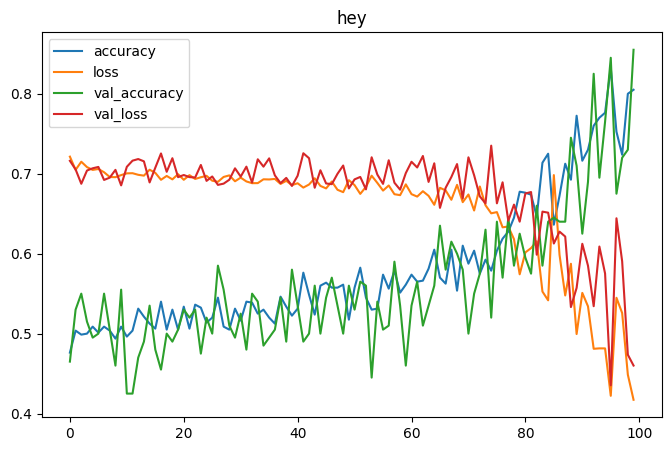

In [9]:
import pandas as pd
pd.DataFrame(train_history.history).plot(figsize=(8,5))
plt.title(f'hey')
# plt.savefig('./Plots/Base_model/7.')
plt.show()

In [9]:
print(np.unique(label))

[0 1]
